In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "conda"
cfe.logger.setLevel("DEBUG")

[07/21/2025 06:52:12] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

数据

In [2]:
cluster_key = "clusters"
fadata = cfe.data.read_pancrease(n_obs=500 ,save_cluster_key=cluster_key)
fadata

[07/21/2025 06:52:13] DEBUG    sample 1 cells for every cluster                                                                                                                                         
                      DEBUG    sample random cells                                                                                                                                                      
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    FateAnnData add_trajectory                                                                                                                                               


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
# cluster_key = "milestone_color"
# fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

# basis = "umap"
# cluster_key_list = ["milestone", cluster_key]
# cfe.plot.plot_graph(fadata, color=cluster_key_list)
# cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [ ]:
method = cfe.method.FateMethod(method_name="velovi")

prior_information = {}
parameters = {
    # use simple model
    # "velovi_model_kwargs": {
    #     "n_hidden": 64,
    #     "n_latent": 8,
    #     },
    "velovi_train_kwargs": {"max_epochs": 10}
    }
fadata.add_prior_information(**prior_information)  # add prior information to fadata

method.infer_trajectory(fadata, parameters=parameters)  # add parameters when inferring trajectory

[07/21/2025 06:53:00] DEBUG    CondaBackend __init__                                                                                                                                                    
                      INFO     method_backend: <cfe.method.fate_conda_backend.CondaBackend object at 0x755140e1ab00>                                                                                    
                      WARNING                                                                                                                                                                           
                                               Prior information cluster_key is optional, but missing from dataset 20250721_185213__FateAnnData__XAqhnMFxJP.                                            
                                                                                                                                                                                                    

[07/21/2025 06:52:47] INFO     find wrapper type: velocity                                                                                                                                              


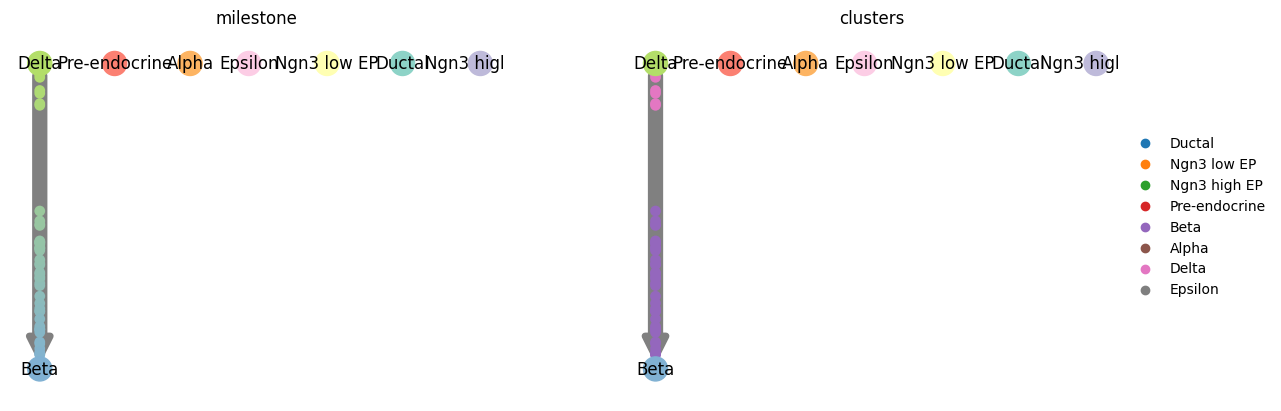

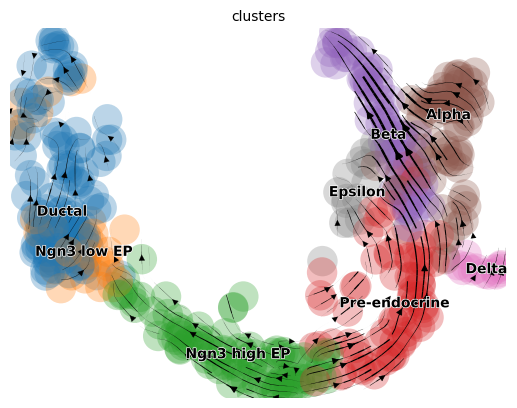

In [5]:
# TODO: _calculate_geodesic_distances function crash on unconnected milestone network
basis = "umap"
cluster_key_list = ["milestone", cluster_key]
# cfe.plot.plot_trajectory(fadata, basis=basis, color="clusters")
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_wrapper(fadata)